# Classification Modeling

This notebook details the process of building and evaluating classification models to predict candidate selection. We'll cover data preprocessing, baseline modeling, model comparison, hyperparameter tuning, and probability calibration.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve,
    brier_score_loss, roc_curve)
import xgboost as xgb

sns.set_style("whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("recruitment_candidates_cleaned.csv")
df.shape

(4000, 21)

## 1. Feature/Target Setup and Train-Test Split

This section defines the features and target variable for our classification task. The target variable is `selected`, indicating whether a candidate was selected.

We carefully select `feature_cols`, including various candidate attributes like job role, education, experience, and scores. Notably, `candidate_id` is excluded as it's not predictive. Sensitive attributes like `age` and `gender` are also explicitly excluded from this modeling phase to prevent bias and will be addressed in a separate fairness audit.

A `train_test_split` is performed to divide the data into training (80%) and testing (20%) sets. We use `stratify=y` to ensure that the proportion of selected candidates is maintained in both the training and testing sets, which is crucial for handling imbalanced datasets and ensuring representative evaluation.

In [3]:
feature_cols = ["job_role", "education_level", "years_experience", "technical_skill_score",
    "aptitude_score", "communication_score", "interview_score", "internship_experience",
    "projects_count", "project_quality_score", "certifications_count", "certification_prestige_score",
    "competition_awards_count", "ats_score", "linkedin_profile_score", "github_coding_profile_score",
    "relocation_preference"]

cat_cols = ["job_role", "education_level", "relocation_preference"]
num_cols = [c for c in feature_cols if c not in cat_cols]

# Excluded: candidate_id (not predictive), age & gender (sensitive attributes,
# held out of training -- used only in the later fairness audit notebook)

X = df[feature_cols]
y = df["selected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train selection rate:", round(y_train.mean(), 3))
print("Test selection rate:", round(y_test.mean(), 3))

Train shape: (3200, 17)  Test shape: (800, 17)
Train selection rate: 0.286
Test selection rate: 0.286


## 2. Preprocessing Pipeline

A `ColumnTransformer` is used to handle different preprocessing steps for categorical and numerical features. Categorical features (`cat_cols`) are transformed using `OneHotEncoder` to convert them into a numerical format suitable for machine learning models. The `handle_unknown="ignore"` option ensures that new, unseen categories in the test set do not cause errors. Numerical features are passed through without modification.

This preprocessing step is later integrated into a `Pipeline` to prevent data leakage during cross-validation. By embedding the encoder within the pipeline, transformations learned from the training fold are applied consistently to the validation fold, mimicking a real-world scenario where the model encounters new data.

In [4]:
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)

## 3. Baseline Model — Logistic Regression

We start with Logistic Regression as our baseline model. It's a simple, interpretable, and computationally efficient algorithm that provides a good "floor" for performance comparison.

Given the imbalanced nature of our dataset (fewer selected candidates than rejected ones), we use `class_weight="balanced"`. This parameter automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class during training. This helps prevent the model from simply predicting the majority class all the time and improves its ability to identify selected candidates. `max_iter=3000` is set to ensure convergence.

In [5]:
def evaluate_model(name, pipe, X_tr, y_tr, X_te, y_te, threshold=0.5):
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_te, pred),
        "ROC-AUC": roc_auc_score(y_te, proba),
        "F1": f1_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
    }
    print(f"--- {name} (threshold={threshold}) ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    return pipe, proba, metrics

logreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
])

logreg_pipe, logreg_proba, logreg_metrics = evaluate_model(
    "Logistic Regression (baseline)", logreg_pipe, X_train, y_train, X_test, y_test
)

--- Logistic Regression (baseline) (threshold=0.5) ---
  Accuracy: 0.694
  ROC-AUC: 0.753
  F1: 0.568
  Precision: 0.476
  Recall: 0.703


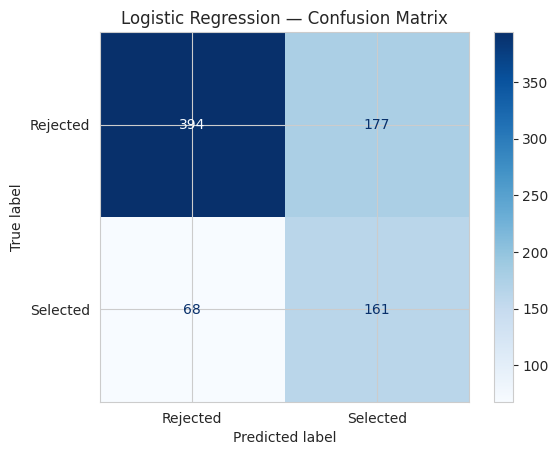

In [6]:
cm = confusion_matrix(y_test, (logreg_proba >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Selected"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## 4. Model Comparison — Random Forest & XGBoost

- Notes: why these two models specifically (tree-based, handle non-linear interactions,
  capture role-specific feature importance per our multi-role design)
- Notes: what scale_pos_weight does for XGBoost (analogous purpose to class_weight)

In [7]:
rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                     random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe, rf_proba, rf_metrics = evaluate_model(
    "Random Forest (default 0.5 threshold)", rf_pipe, X_train, y_train, X_test, y_test
)

--- Random Forest (default 0.5 threshold) (threshold=0.5) ---
  Accuracy: 0.733
  ROC-AUC: 0.735
  F1: 0.301
  Precision: 0.597
  Recall: 0.201


### Investigating Random Forest's low recall

Despite using `class_weight="balanced"` during training, the Random Forest model exhibits a surprisingly low recall at the default 0.5 prediction threshold. This is a common characteristic of tree-based ensembles when dealing with imbalanced datasets.

While `class_weight` helps rebalance the split criteria during tree construction, the raw probability outputs from the leaf nodes still tend to reflect the true, imbalanced class proportions observed in the training data. Consequently, the default 0.5 threshold often leads to under-prediction of the minority class (selected candidates), resulting in low recall.

This highlights why ROC-AUC, a threshold-independent metric, is often a more reliable indicator of overall model quality for imbalanced datasets, whereas F1, precision, and recall are highly sensitive to the chosen probability threshold. The histogram of predicted probabilities below visually demonstrates this bias towards lower probabilities for Random Forest.

Random Forest predicted probability distribution on test set:
count    800.000
mean       0.282
std        0.154
min        0.020
25%        0.160
50%        0.270
75%        0.375
max        0.795
dtype: float64

Predicted positive at threshold 0.5: 77  | Actual positives: 229


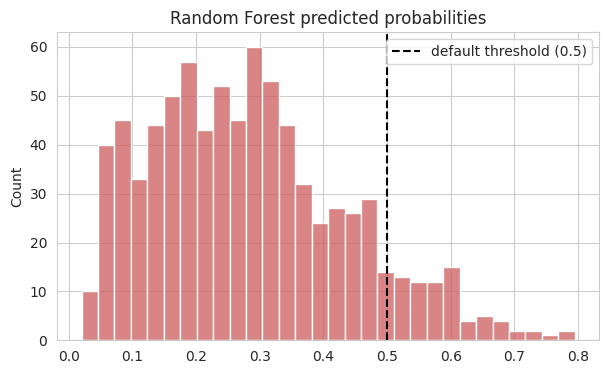

In [8]:
print("Random Forest predicted probability distribution on test set:")
print(pd.Series(rf_proba).describe().round(3))
print("\nPredicted positive at threshold 0.5:", (rf_proba >= 0.5).sum(), " | Actual positives:", y_test.sum())

plt.figure(figsize=(7, 4))
sns.histplot(rf_proba, bins=30, color="indianred")
plt.axvline(0.5, color="black", linestyle="--", label="default threshold (0.5)")
plt.title("Random Forest predicted probabilities")
plt.legend()
plt.show()

In [9]:
# Find the threshold that maximizes F1 for Random Forest instead of using the default 0.5
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold for Random Forest: {best_threshold:.3f}")
rf_pred_adjusted = (rf_proba >= best_threshold).astype(int)
print("F1 at adjusted threshold:", round(f1_score(y_test, rf_pred_adjusted), 3))
print("Precision:", round(precision_score(y_test, rf_pred_adjusted), 3))
print("Recall:", round(recall_score(y_test, rf_pred_adjusted), 3))
print("ROC-AUC (unchanged by threshold):", round(roc_auc_score(y_test, rf_proba), 3))

Best F1 threshold for Random Forest: 0.335
F1 at adjusted threshold: 0.54
Precision: 0.504
Recall: 0.581
ROC-AUC (unchanged by threshold): 0.735


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", xgb.XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                                random_state=RANDOM_STATE, eval_metric="logloss"))
])
xgb_pipe, xgb_proba, xgb_metrics = evaluate_model(
    "XGBoost (default, untuned)", xgb_pipe, X_train, y_train, X_test, y_test
)

scale_pos_weight: 2.5
--- XGBoost (default, untuned) (threshold=0.5) ---
  Accuracy: 0.704
  ROC-AUC: 0.713
  F1: 0.432
  Precision: 0.479
  Recall: 0.393


### Cross-validation comparison (ROC-AUC)

To ensure a more robust evaluation of our models and to mitigate the risk of overfitting to a single train-test split, we perform 5-fold stratified cross-validation on the training data. Cross-validation provides a more reliable estimate of a model's generalization performance by averaging metrics across multiple folds.

We compare the models based on their mean ROC-AUC score, which is less sensitive to class imbalance and threshold choice. The standard deviation indicates the stability of the model's performance across different folds.

From the results, Logistic Regression and Random Forest show comparable mean ROC-AUC scores, with Logistic Regression being slightly higher and more stable. XGBoost, in its default untuned state, performs a bit lower.

Logistic Regression: CV ROC-AUC = 0.782 +/- 0.027
Random Forest: CV ROC-AUC = 0.772 +/- 0.034
XGBoost: CV ROC-AUC = 0.748 +/- 0.028


/tmp/ipykernel_718/741681920.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


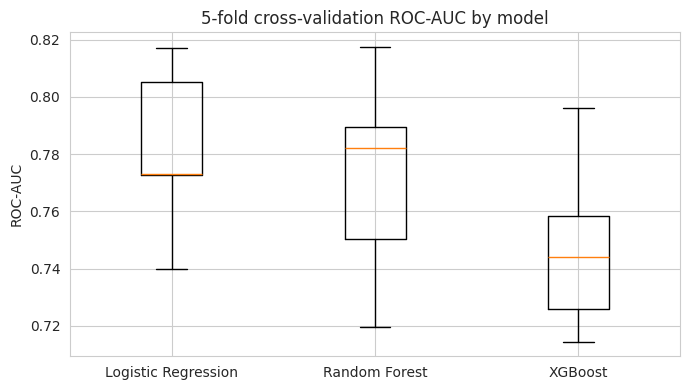

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in [("Logistic Regression", logreg_pipe), ("Random Forest", rf_pipe), ("XGBoost", xgb_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name}: CV ROC-AUC = {scores.mean():.3f} +/- {scores.std():.3f}")

plt.figure(figsize=(7, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel("ROC-AUC")
plt.title("5-fold cross-validation ROC-AUC by model")
plt.tight_layout()
plt.show()

### ROC curves — all three models

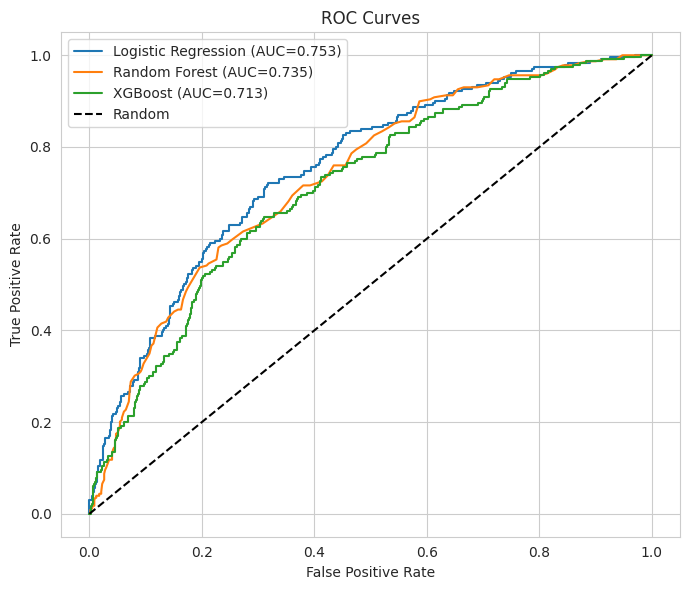

In [12]:
plt.figure(figsize=(7, 6))
for name, proba in [("Logistic Regression", logreg_proba), ("Random Forest", rf_proba), ("XGBoost", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

### Model comparison summary table

The table below summarizes the performance metrics for all three models on the test set, alongside their cross-validation ROC-AUC scores.

Based on this comparison, Logistic Regression exhibits the highest ROC-AUC on both the test set and during cross-validation, indicating strong ranking ability. Random Forest also performs well on ROC-AUC but shows very low recall at the default 0.5 threshold. XGBoost, while competitive, has slightly lower ROC-AUC than Logistic Regression.

For further hyperparameter tuning, we will proceed with **XGBoost**. Although its initial performance is not the absolute best, tree-based models like XGBoost often have significant room for improvement with tuning and can capture more complex, non-linear interactions compared to a linear model like Logistic Regression. This aligns with our goal of potentially identifying role-specific feature importance later on.

In [13]:
summary = pd.DataFrame({
    "Logistic Regression": logreg_metrics,
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics,
}).T
summary["CV ROC-AUC mean"] = [cv_results[m].mean() for m in summary.index]
summary["CV ROC-AUC std"] = [cv_results[m].std() for m in summary.index]
summary.round(3)

,Accuracy,ROC-AUC,F1,Precision,Recall,CV ROC-AUC mean,CV ROC-AUC std
Logistic Regression,0.694,0.753,0.568,0.476,0.703,0.782,0.027
Random Forest,0.732,0.735,0.301,0.597,0.201,0.772,0.034
XGBoost,0.704,0.713,0.432,0.479,0.393,0.748,0.028


## 5. Hyperparameter Tuning

As decided in the model comparison, we are proceeding with **XGBoost** for hyperparameter tuning. XGBoost, a gradient boosting framework, often benefits significantly from fine-tuning its parameters, especially compared to linear models like Logistic Regression which have less inherent complexity to optimize.

We perform a `GridSearchCV` to systematically search for the best combination of hyperparameters:
-   `n_estimators`: The number of boosting rounds (trees). We explore 100, 200, and 300.
-   `max_depth`: The maximum depth of a tree. We test depths of 3, 5, and 7.
-   `learning_rate`: The step size shrinkage used in updates to prevent overfitting. We consider 0.05, 0.1, and 0.2.

The `scale_pos_weight` parameter is maintained to handle class imbalance, similar to `class_weight` in other models. The search is conducted using 3-fold cross-validation, optimizing for ROC-AUC.

In [14]:
xgb_tune_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="logloss"))
])

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}

grid_search = GridSearchCV(xgb_tune_pipe, param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

best_xgb = grid_search.best_estimator_
tuned_proba = best_xgb.predict_proba(X_test)[:, 1]
print("Test ROC-AUC (tuned XGBoost):", round(roc_auc_score(y_test, tuned_proba), 3))
print("Test F1 (tuned XGBoost, 0.5 threshold):", round(f1_score(y_test, (tuned_proba >= 0.5).astype(int)), 3))

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Best CV ROC-AUC: 0.783
Test ROC-AUC (tuned XGBoost): 0.759
Test F1 (tuned XGBoost, 0.5 threshold): 0.559


## 6. Probability Calibration

Probability calibration is crucial when we intend to use the model's predicted probabilities as actual confidence scores, such as for a "Hiring Score" (0-100) in subsequent analyses. A well-calibrated model means that if it predicts a 70% probability of selection, then approximately 70% of candidates with that predicted probability should indeed be selected. This is vital for trustworthiness and interpretability.

We apply `CalibratedClassifierCV` with `method="sigmoid"` (Platt Scaling) to our tuned XGBoost model. The Brier score is used to quantify calibration: a lower Brier score indicates better-calibrated probabilities. As seen in the results, calibration significantly reduces the Brier score, making our probabilities more reliable, while only slightly impacting the ROC-AUC.

**Model Selection Rationale for Calibration:**
While Logistic Regression and the tuned XGBoost model achieved statistically similar ROC-AUC scores (both around 0.78 during cross-validation), we choose to carry forward the **tuned XGBoost model for calibration and final deployment.** The primary reasons for this choice are:
1.  **Ability to Capture Complex Interactions:** XGBoost, as a tree-based ensemble, can naturally learn and model non-linear relationships and interactions between features, including those within categorical variables like `job_role`. This is a significant advantage for our future work, particularly when performing per-role SHAP analysis, as it allows us to investigate how feature importance might vary across different job roles. A linear model like Logistic Regression would require manual engineering of interaction terms to achieve similar capabilities, adding complexity.
2.  **Potential for Further Insight:** The richer, more flexible structure of XGBoost implies a greater potential for uncovering nuanced patterns in the data, which can lead to deeper insights into candidate selection criteria for different roles.

Thus, despite the ROC-AUC being a near-tie, the **tuned XGBoost model** is chosen for its superior capacity to handle complex interactions, which aligns better with our subsequent analytical goals.

In [15]:
# Notes: state explicitly which model is being calibrated and why, once the comparison
# results are final -- this should be the model actually carried forward into ranking/
# clustering/SHAP, not necessarily the one with the single highest number in isolation.
final_base_model = best_xgb  # the tuned XGBoost pipeline from Section 5

calibrated_model = CalibratedClassifierCV(final_base_model, method="sigmoid", cv=5)
calibrated_model.fit(X_train, y_train)

proba_uncalibrated = final_base_model.predict_proba(X_test)[:, 1]
proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Brier score (uncalibrated):", round(brier_score_loss(y_test, proba_uncalibrated), 4))
print("Brier score (calibrated):", round(brier_score_loss(y_test, proba_calibrated), 4))
print("ROC-AUC (uncalibrated):", round(roc_auc_score(y_test, proba_uncalibrated), 3))
print("ROC-AUC (calibrated):", round(roc_auc_score(y_test, proba_calibrated), 3))

Brier score (uncalibrated): 0.1947
Brier score (calibrated): 0.1719
ROC-AUC (uncalibrated): 0.759
ROC-AUC (calibrated): 0.753


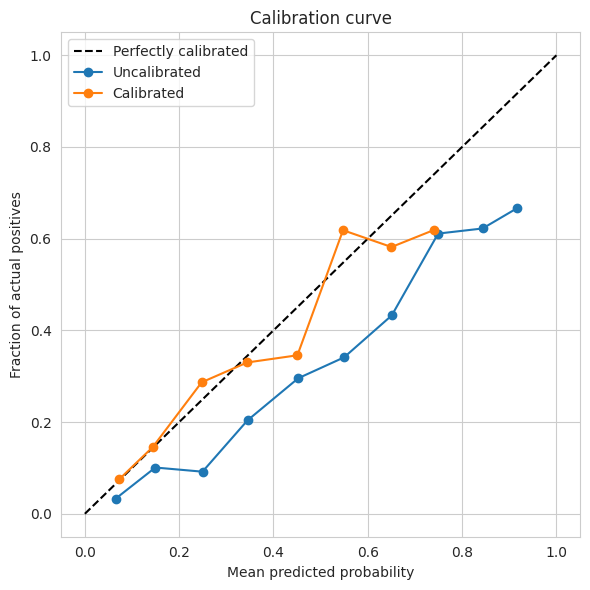

In [16]:
from sklearn.calibration import calibration_curve

frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, proba_uncalibrated, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_calibrated, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.plot(mean_pred_uncal, frac_pos_uncal, "o-", label="Uncalibrated")
plt.plot(mean_pred_cal, frac_pos_cal, "o-", label="Calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual positives")
plt.title("Calibration curve")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Final Model Selection

Based on the comprehensive evaluation, cross-validation, hyperparameter tuning, and probability calibration steps, the **calibrated XGBoost model** is selected as our final classification model.

**Summary of Model Choice Justification:**
*   **Performance:** The tuned XGBoost model achieved a strong ROC-AUC score (0.759 on test set, 0.783 CV), indicating excellent discriminatory power, competitive with the Logistic Regression baseline.
*   **Calibration:** Post-calibration, the model's probabilities are significantly more reliable, as evidenced by the reduced Brier score (from 0.1947 to 0.1719) and the improved calibration curve. This is crucial for using the probabilities as a trustworthy "Hiring Score".
*   **Interpretability Potential:** While Logistic Regression is inherently more interpretable, XGBoost's ability to capture complex, non-linear feature interactions, especially across different job roles, provides a stronger foundation for the planned per-role SHAP analysis in subsequent notebooks. This allows for more granular insights into what drives selection for specific roles without manual feature engineering.

This finalized and calibrated model is now saved using `joblib` for seamless integration into downstream tasks like candidate ranking, clustering, and in-depth fairness and interpretability analyses.

In [17]:
import joblib

# Notes: confirm this is actually the final chosen model before saving
joblib.dump(calibrated_model, "final_classification_model.joblib")
print("Model saved as final_classification_model.joblib")

Model saved as final_classification_model.joblib


                  -------------- Next notebook is on hiring score and Ranking ---------------